# Predicting Productivity of Garment Employees 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
garment = pd.read_csv('garments_worker_productivity.csv')
#Check if data loaded properly 
print(garment.head())

       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1                   0            8.0        

## Data Dictionary 

- `Date`: date in MM-DD-YYYY
- `Quarter`: a portion of the month — month was divided into four quarters
- `Department`: associated department with the instance
- `Day` : day of the week     
- `Team`: associated team number with the instance
- `Targeted_productivity`: targeted productivity set by the authority for each team for each day
- `Smv`: standard minute value — the allocated time for a task  
- `Wip`: work in progress — includes the number of unfinished items for products 
- `Over_time`: represents the amount of overtime by each team in minutes       
- `Incentive`: represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action               
- `Idle_time`: the duration of time when the production was interrupted due to several reasons                
- `Idle_men`: the number of workers who were idle due to production interruption              
- `No_of_style_change`: number of changes in the style of a particular product 
- `No_of_workers`: number of workers on each team       
- `Actual_productivity`: the actual % of productivity that was delivered by the workers — it ranges from 0 to 1.

## Data Exploration

We are going to explore our data and determine if there are any trends and/or anomalies that stand out to us that can help us later build our model. 

In [2]:
print(garment.info(), '\n')
print(f'Number of features: {garment.shape[1]}','\n')
print(f'Number of observations: {garment.shape[0]}','\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

We are going to visualize our features in the dataset to determine the general shape of each feature and if there is anything that stands out to us. Additionally, we will also determine if there are any missing values we should account for.

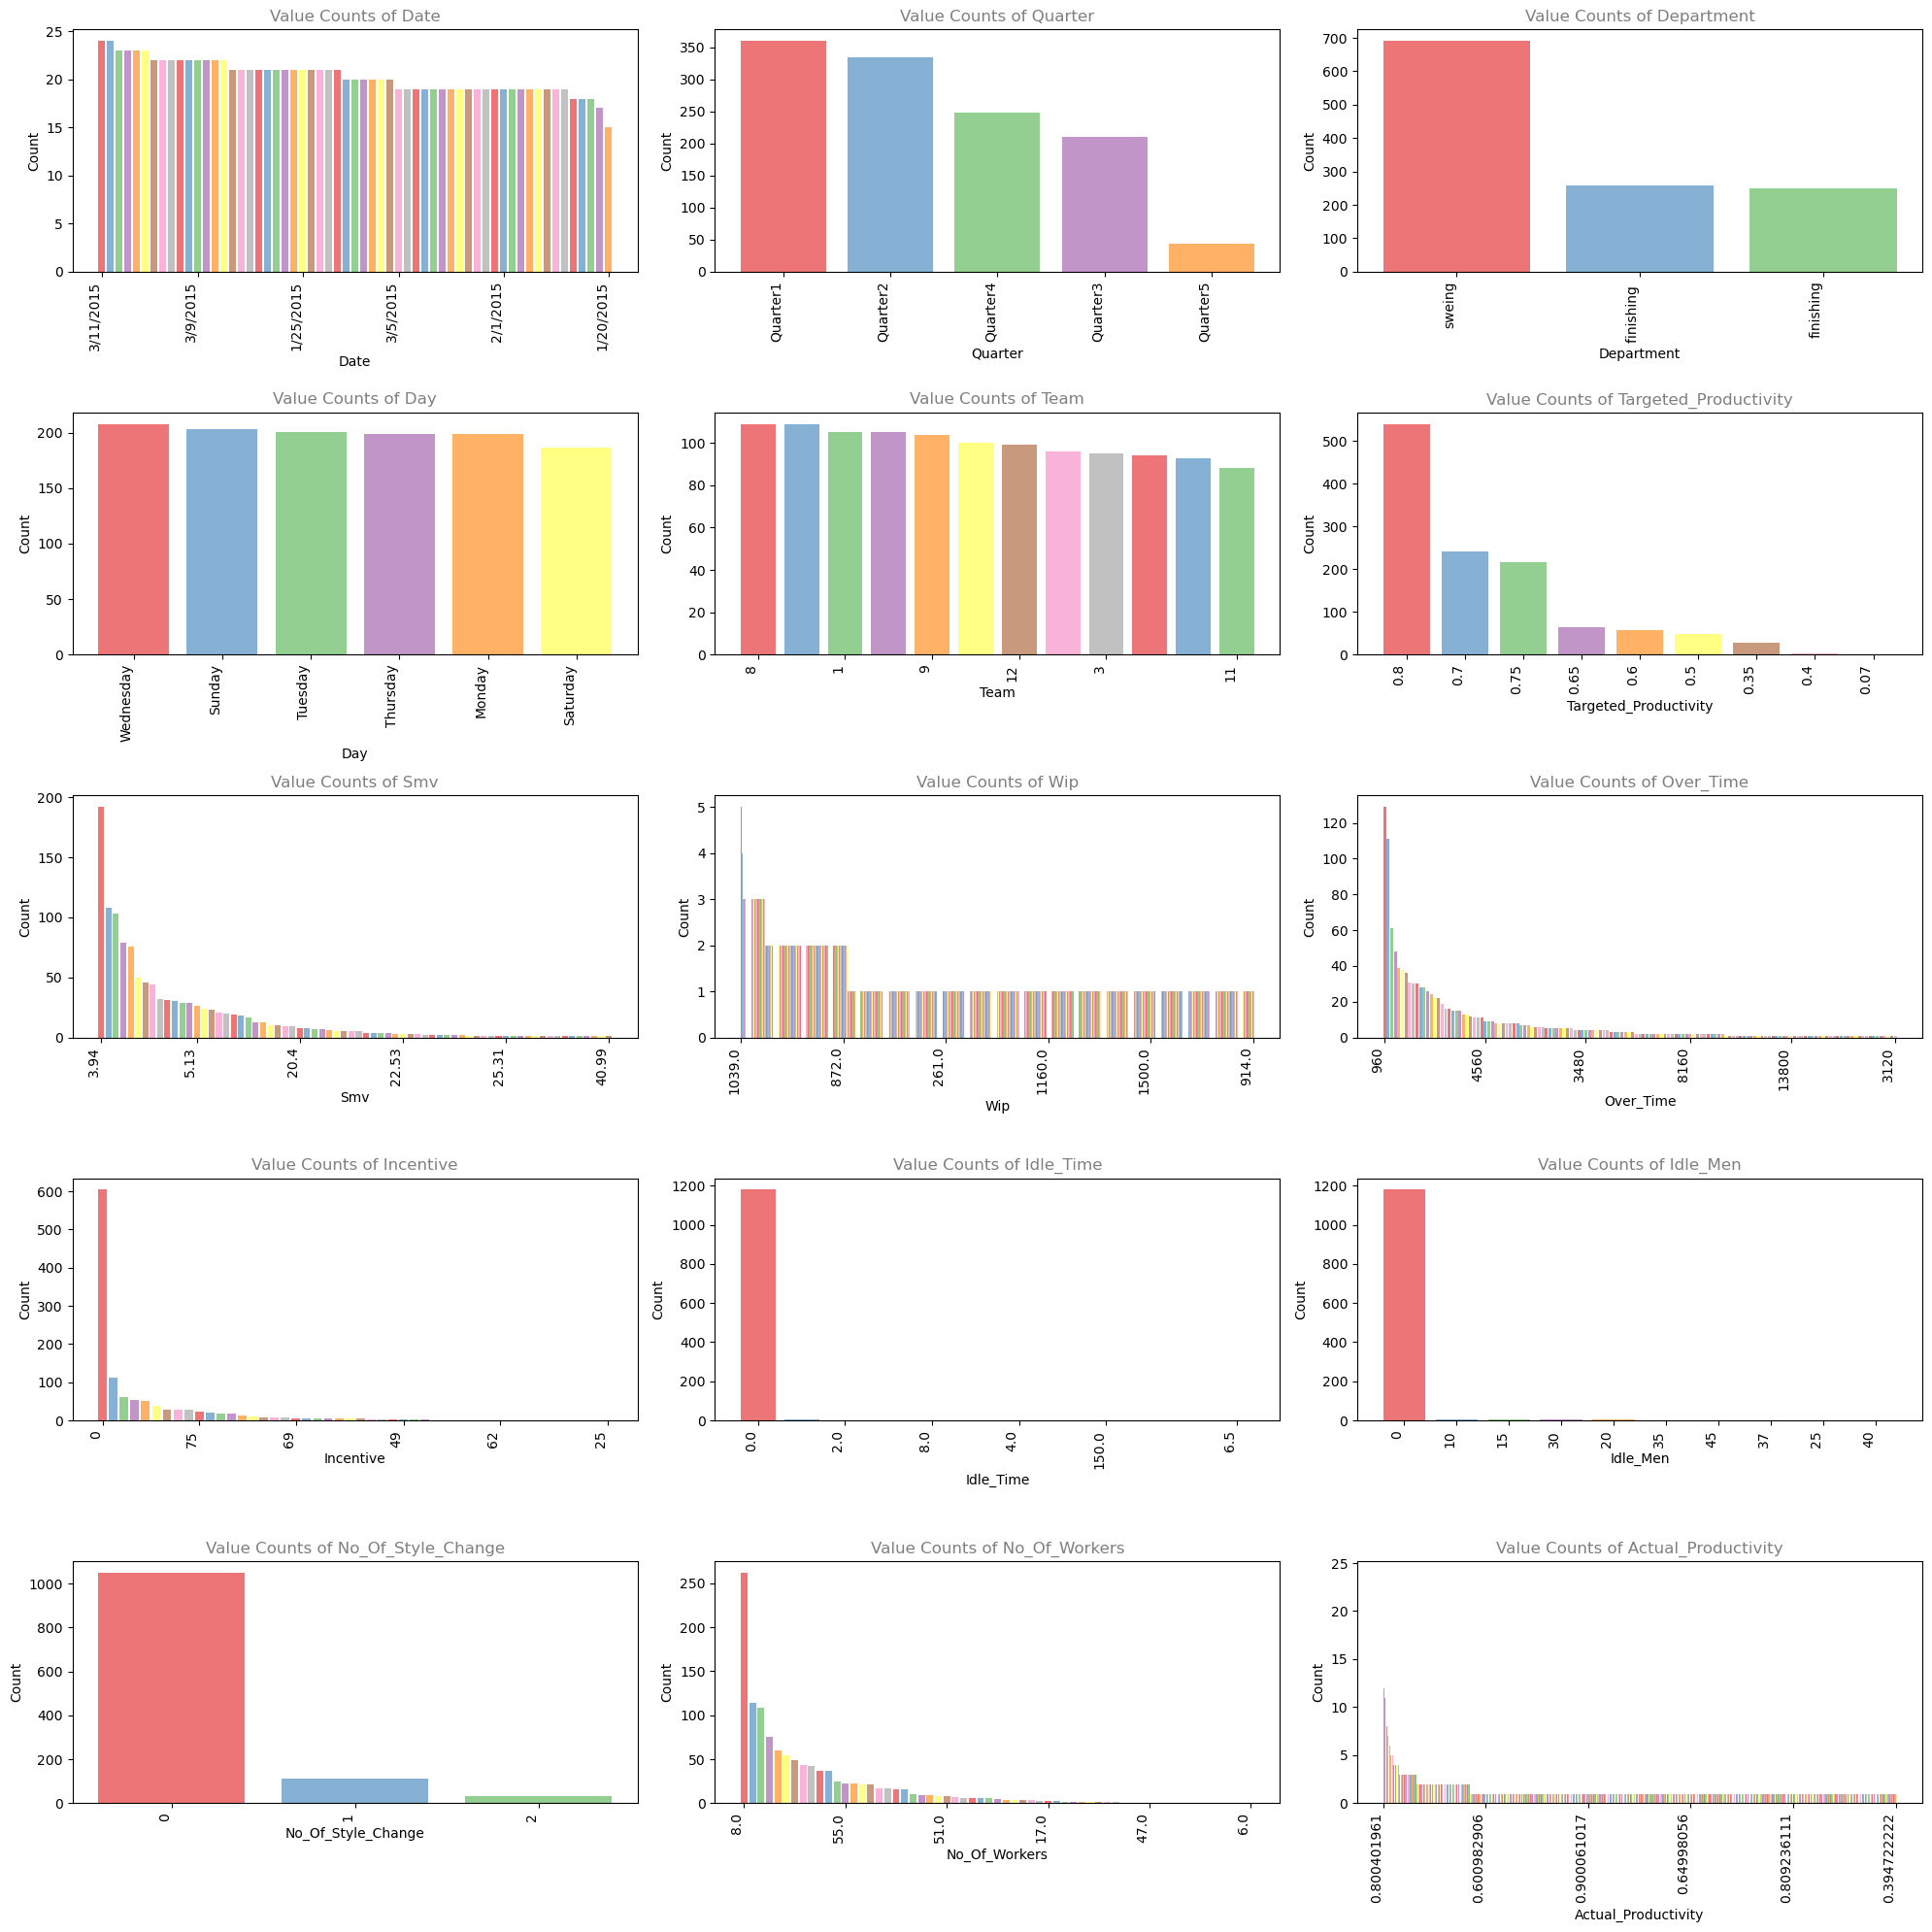

In [3]:
#Visualizing shape of our features 

fig, axes = plt.subplots(5, 3, figsize =(20,20)) 
axes = axes.flatten()

for i, column in enumerate(garment.columns):
    df_plot = garment[column].value_counts()
    axes[i].bar(df_plot.index.astype(str), df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    axes[i].set_title(f'Value Counts of {column.title()}', alpha=0.5)
    axes[i].set_xlabel(column.title())
    axes[i].set_ylabel('Count')
    if len(df_plot) > 10:
        num_labels = 6 
        x_ticks = np.linspace(0, len(df_plot) - 1, num_labels).astype(int)
        axes[i].set_xticks(x_ticks)
        axes[i].set_xticklabels(df_plot.index[x_ticks], rotation=90, ha='right')  # Set labels for those positions
    else:
        axes[i].set_xticks(np.arange(len(df_plot)))
        axes[i].set_xticklabels(df_plot.index, rotation=90, ha='right')

plt.tight_layout()  
plt.show()

In [4]:
#Finding missing values
garment.isna().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

Based on our the distribution of our charts, here are some observations that stand out to investigate further: 

- `Date`: Nothing to note. 
- `Quarter`: We have five quarters instead of the usual four. We should investigate the dates in this dataset to determine why. 
- `Department`: Sewing is spelled incorrectly and the finishing deparment appears twice. We should fix that in the dataset. 
- `Day` : No observations for Friday. Could be a holiday.      
- `Team`: Nothing to note. 
- `Targeted_productivity`: Will investigate with actual productivity. 
- `Smv`:  Nothing to note.                       
- `Wip`: Has 506 missing values. We can omit this column in our model or replace the missing values with another value.   
- `Over_time`: Nothing to note.                  
- `Incentive`: Nothing to note.                  
- `Idle_time`: All values are 0.0. No useful information provided, therefore will omit these features.                 
- `Idle_men`: All values are 0.0. No useful information provided, therefore will omit these features.                 
- `No_of_style_change`: Nothing to note.        
- `No_of_workers`: Nothing to note.          
- `Actual_productivity`: Will invesitgate with targeted productivity. 

Now that we have our general findings about the features, we will dive deeper into cleaning up this data. 

## Data Cleaning 

#### Date and Quarter

We noticed that the quarter column had 5 quarters which is an unusual number. Let's explore the dates in the dataset. 

In [5]:
garment['date'] = pd.to_datetime(garment['date'])
garment['date'].dt.strftime('%m-%d-%Y').value_counts().sort_index(ascending=True)

01-01-2015    19
01-03-2015    21
01-04-2015    21
01-05-2015    22
01-06-2015    21
01-07-2015    22
01-08-2015    22
01-10-2015    22
01-11-2015    23
01-12-2015    23
01-13-2015    22
01-14-2015    21
01-15-2015    19
01-17-2015    21
01-18-2015    19
01-19-2015    19
01-20-2015    15
01-21-2015    19
01-22-2015    22
01-24-2015    23
01-25-2015    21
01-26-2015    19
01-27-2015    21
01-28-2015    21
01-29-2015    20
01-31-2015    24
02-01-2015    19
02-02-2015    19
02-03-2015    19
02-04-2015    19
02-05-2015    18
02-07-2015    19
02-08-2015    19
02-09-2015    18
02-10-2015    19
02-11-2015    19
02-12-2015    19
02-14-2015    17
02-15-2015    19
02-16-2015    18
02-17-2015    20
02-18-2015    21
02-19-2015    20
02-22-2015    20
02-23-2015    19
02-24-2015    19
02-25-2015    21
02-26-2015    21
02-28-2015    21
03-01-2015    20
03-02-2015    20
03-03-2015    22
03-04-2015    21
03-05-2015    19
03-07-2015    19
03-08-2015    22
03-09-2015    22
03-10-2015    23
03-11-2015    

The dates in the date column were from January to March 2015, i.e. these dates did not span the entire year. 

Using the definition given to us for what a quarter was in the data dictionary: a month was divided into four quarters, thus, we can conclude a fifth quarter was an erroneous entry in the data. Let's explore what the fifth quarter dates are.

In [6]:
garment[garment['quarter'] == 'Quarter5'][['date', 'quarter']]

,date,quarter
498,2015-01-29,Quarter5
499,2015-01-29,Quarter5
500,2015-01-29,Quarter5
501,2015-01-29,Quarter5
502,2015-01-29,Quarter5
503,2015-01-29,Quarter5
504,2015-01-29,Quarter5
505,2015-01-29,Quarter5
506,2015-01-29,Quarter5
507,2015-01-29,Quarter5


We can see that for the last couple days of the month in January they were noted as quarter 5. We can replace this value with quarter 4. 

In [7]:
garment.loc[garment['quarter'] == 'Quarter5', 'quarter'] = 'Quarter4'
garment['quarter'].value_counts()

Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: quarter, dtype: int64

Since we have both a quarter and date column, we are just going to select the Quarter column since the the short period of dates doesn't give us that much information that may be useful for us.

#### Department 

We noticed the department name for sewing was spelled wrong and we have two departments named finishing so we should clean that up. 

In [8]:
garment['department'].value_counts()
garment['department'].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [9]:
garment['department'] = garment['department'].replace({
'sweing': 'sewing', 
'finishing ': 'finishing'
})

garment['department'].value_counts()

sewing       691
finishing    506
Name: department, dtype: int64

#### Wip 

Wip has 506 missing values. We should explore and see what to do with the missing values. 

In [10]:
garment[garment['wip'].isnull()].groupby('department').size()

department
finishing    506
dtype: int64

So all of the wip values that are missing are from the finishing department. Therefore, it wouldn't be accurate to replace the missing values with the average of the dataset because we would be giving the entire dataset the average of the sewing department. Therefore, we should omit this data from our feature selection. 

#### Target and Actual Productivity

Finally, we are going to explore our target and actual productivity. We want productivity to be our target column for our model. Let's explore more about this data.

In [11]:
garment[['targeted_productivity', 'actual_productivity']].describe()

,targeted_productivity,actual_productivity
count,1197.000000,1197.000000
mean,0.729632,0.735091
std,0.097891,0.174488
min,0.070000,0.233705
25%,0.700000,0.650307
50%,0.750000,0.773333
75%,0.800000,0.850253
max,0.800000,1.120437


We see that for actual productivity, we have values that exceed 1. This doesn't make sense since we were given in our data dictionary that our productivity ranged from 0-1. Replacing these values wouldn't make too much sense since we want to eventually use these values to create a boolean for a target column, therefore, for now we will omit them. 

In [12]:
garment_filtered = garment[~(garment['actual_productivity'] > 1)]

Now that we have filtered out these values, we can create a boolean to determine if teams met their targeted productivity or not. This will be the target column in our model. With this, we do not need the actual and targeted productivity columns in our final dataframe due to redundancy. 

In [13]:
garment_filtered_copy = garment_filtered.copy()
garment_filtered_copy['productivity_met'] = garment_filtered_copy['actual_productivity'] > garment_filtered_copy['targeted_productivity']
garment_filtered_copy.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,productivity_met
0,2015-01-01,Quarter1,sewing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,True
1,2015-01-01,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,True
2,2015-01-01,Quarter1,sewing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,True
3,2015-01-01,Quarter1,sewing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,True
4,2015-01-01,Quarter1,sewing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,True


Now that we have have finished cleaning our data and have decided what we want to omit, let's select our final columns and create our dataframe that is going to be used for our model. 

In [14]:
final = garment_filtered_copy[['quarter', 'department', 'day', 'team', 'smv', 'over_time', 'incentive', 'no_of_style_change', 'no_of_workers', 'productivity_met']]
#Creating dummies for our categorical columns 
final = pd.get_dummies(final, drop_first=True)
final.head()

,team,smv,over_time,incentive,no_of_style_change,no_of_workers,productivity_met,quarter_Quarter2,quarter_Quarter3,quarter_Quarter4,department_sewing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,8,26.16,7080,98,0,59.0,True,0,0,0,1,0,0,1,0,0
1,1,3.94,960,0,0,8.0,True,0,0,0,0,0,0,1,0,0
2,11,11.41,3660,50,0,30.5,True,0,0,0,1,0,0,1,0,0
3,12,11.41,3660,50,0,30.5,True,0,0,0,1,0,0,1,0,0
4,6,25.90,1920,50,0,56.0,True,0,0,0,1,0,0,1,0,0


## Instantiating Decision Tree

Now that our data is prepped and we have our selected feature and target columns, we are ready to create a decision tree. We will create a decision tree to classify which characteristics will determine whether a team is productive or not. 

In [15]:
#Importing packages necessary to create and visualize tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

In [16]:
#Creating x and y and splitting dataset into training and testing subsets 
X = final.drop(['productivity_met'], axis = 1)
y = final['productivity_met']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 1, shuffle = True) 

In [17]:
#Creating decision tree 

class_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state = 1)
class_tree.fit(X_train, y_train) 
predictions = class_tree.predict(X_test) 

In [18]:
#Confusion Matrix 
print("Decision Tree Confusion Matrix:", confusion_matrix(y_test, predictions))

#Accuracy Score
print("Decision Tree Accuracy:", round(accuracy_score(y_test, predictions), 2))

#Precision Score
print("Decision Tree Precision:", round(precision_score(y_test, predictions), 2))

#Recall Score
print("Decision Tree Recall:", round(recall_score(y_test, predictions), 2))

#F1 Score
print("Decision Tree F1 Score:", round(f1_score(y_test, predictions), 2))

Decision Tree Confusion Matrix: [[ 24  40]
 [  8 160]]
Decision Tree Accuracy: 0.79
Decision Tree Precision: 0.8
Decision Tree Recall: 0.95
Decision Tree F1 Score: 0.87


#### Confusion Matrix 
- True Negatives (TN): 24 
- False Positives (FP): 40 
- False Negatives (FN): 8 
- True Positives (TP): 160 

#### Accuracy: 0.79

The model correctly classified 79% of all test data. 

#### Precision: 0.80

The model correctly classified 80% of predicted positive classes. 

#### Recall: 0.95

The model correctly classified 95% of all actual positive classes.  

#### F1 Score: 0.87

An F1 score of 0.87 indicates a good balance between precision and recall.

In [19]:
#Cross validation 

from sklearn.model_selection import cross_validate

multiple_cross = cross_validate(class_tree, X, y, scoring= ('accuracy','precision', 'recall', 'f1'))

#Accuracy Score
print("CV Accuracy:", round(multiple_cross['test_accuracy'].mean(), 2))

#Precision Score
print("CV Precision:", round(multiple_cross['test_precision'].mean(), 2))

#Recall Score
print("CV Recall:", round(multiple_cross['test_recall'].mean(), 2))

#F1 Score
print("CV F1 Score:", round(multiple_cross['test_f1'].mean(), 2))

CV Accuracy: 0.76
CV Precision: 0.81
CV Recall: 0.88
CV F1 Score: 0.84


#### Accuracy: 0.76

The model correctly classified 76% of all test data across validation folds.

#### Precision: 0.81

The model correctly classified 81% of predicted positive classes across validation folds. 

#### Recall: 0.88

The model correctly classified 88% of all actual positive classes across validation folds.

#### F1 Score: 0.84

An F1 score of 0.84 indicates a good balance between precision and recall across validation folds.

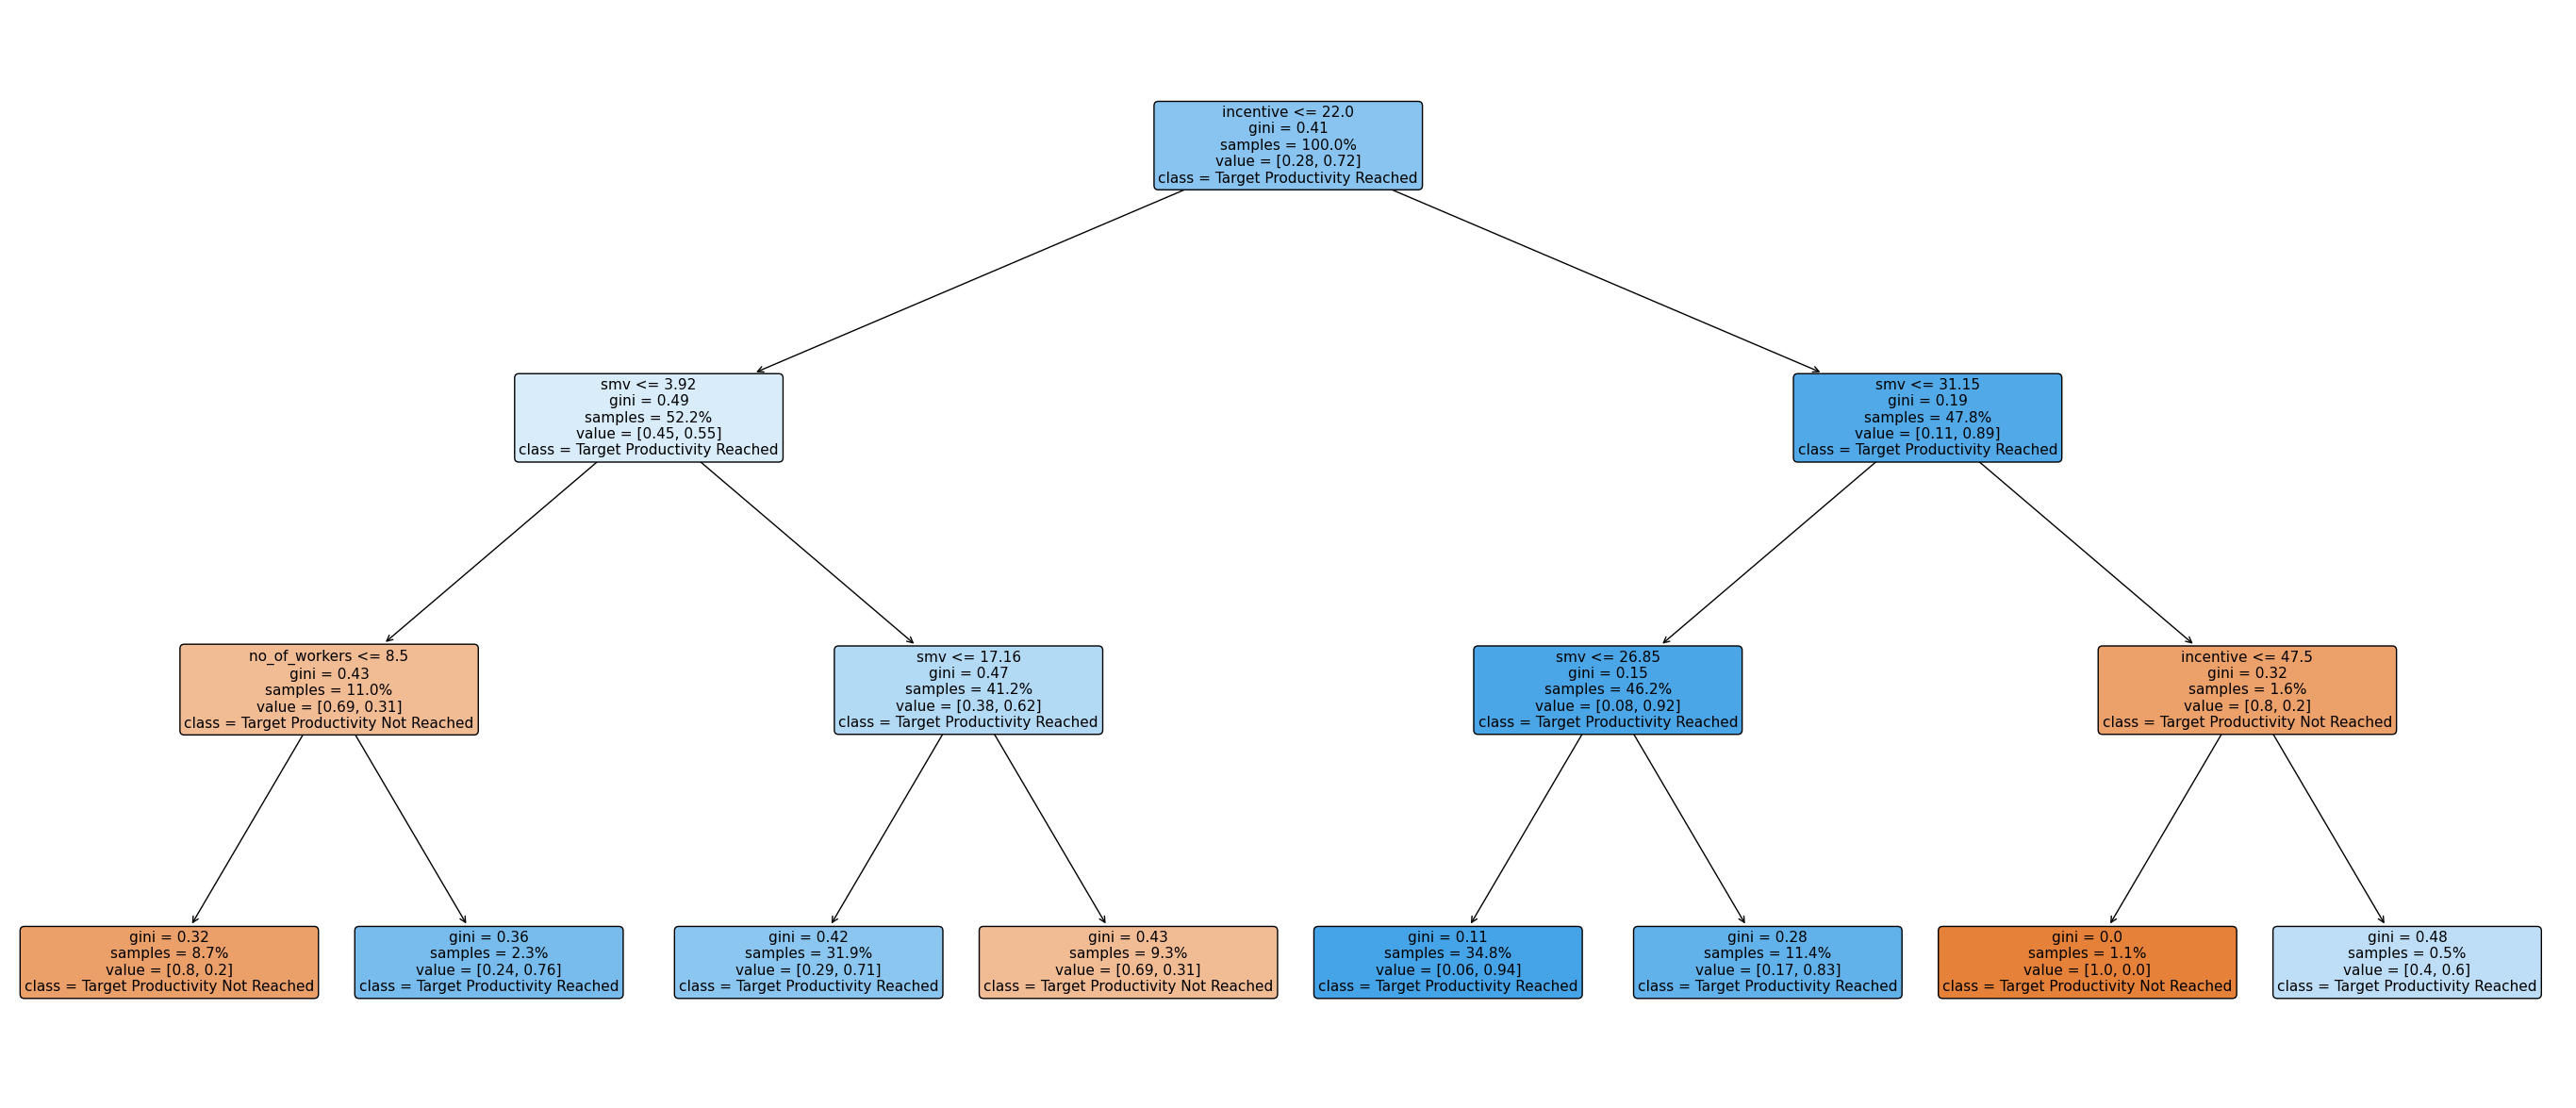

In [20]:
#Visualizing decision tree 

plt.figure(figsize = [35, 15])

# Plotting the tree with some specific parameters

_ = plot_tree(class_tree, 
              feature_names = X.columns, 
              class_names = ["Target Productivity Not Reached", "Target Productivity Reached"],
              filled = True,       
              proportion = True,
              precision = 2,
              rounded = True,
              fontsize = 11) 

We placed a max depth for our decision tree to be 3 levels to prevent out tree from overfitting. It looks like based on our tree, the incentive and smv features have the most influences on determining whether or not a team will meet their target productivity or not. By focusing on areas like adjusting incentives or reducing time spent on a task, we can drive improvements in operational efficiency.

## Instantiating Random Forest 

Finally, to mitigate any effects of overfitting and to confirm the performance metrics of our decision tree, we are going to instantiate a random forest. 

In [21]:
#Instantiating Random Forest 

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model with specified parameters
forest = RandomForestClassifier(
    max_depth=3,
    n_jobs=-1,
    random_state=1,
    bootstrap= True,
    oob_score = True
)

forest.fit(X_train, y_train)

forest_predictions = forest.predict(X_test)

# Evaluate the model
#Confusion Matrix 
print("Random Forest Confusion Matrix:", confusion_matrix(y_test, forest_predictions))

#Accuracy Score
print("Random Forest Accuracy:", round(accuracy_score(y_test, forest_predictions), 2))

#Precision Score
print("Random Forest Precision:", round(precision_score(y_test, forest_predictions), 2))

#Recall Score
print("Random Forest Recall:", round(recall_score(y_test, forest_predictions), 2))

#F1 Score
print("Random Forest F1 Score:", round(f1_score(y_test, forest_predictions), 2))

Random Forest Confusion Matrix: [[ 15  49]
 [  2 166]]
Random Forest Accuracy: 0.78
Random Forest Precision: 0.77
Random Forest Recall: 0.99
Random Forest F1 Score: 0.87


#### Confusion Matrix
True Negatives (TN): 15
False Positives (FP): 49
False Negatives (FN): 2
True Positives (TP): 166

#### Accuracy: 0.78

The model correctly classified 78% of all test data across validation folds.

#### Precision: 0.77

The model correctly classified 77% of predicted positive classes across validation folds. 

#### Recall: 0.99

The model correctly classified 99% of all actual positive classes across validation folds.

#### F1 Score: 0.87

An F1 score of 0.87 indicates a good balance between precision and recall across validation folds.

## Final Thoughts 

Based on our performance metrics for the random forest, they are relatively close to the metrics provided from our decision tree, therefore, we can be fairly confident about our results. 

Thus, we can share that to predict team performance, business leaders should focus on time spent on a task (smv) and the amount of incentives (incentive). 

Things to note based on our metrics from our random forest, we had a higher recall than precision which means that our model was good at predicting actual positive instances, but is also flagging some true negatives as a false positive. 

For a future iteration, we can adjust the decision threshold to better balance precision and recall better.